# Experiment 10: Transformer Model from Scratch using PyTorch

**Objective:** Implement a Transformer model with Encoder and Decoder from scratch using PyTorch and train it on the Shakespeare dataset for character-level language modelling.

**Dataset:** [Shakespeare text — MIT OCW](https://ocw.mit.edu/ans7870/6/6.006/s08/lecturenotes/files/t8.shakespeare.txt)

---
### Architecture Overview
| Component | Details |
|---|---|
| Input Embedding | Character-level token embeddings |
| Positional Encoding | Sinusoidal (fixed) |
| Encoder | N × (Multi-Head Self-Attention + FFN) |
| Decoder | N × (Masked Self-Attention + Cross-Attention + FFN) |
| Output | Linear + Softmax over vocabulary |

## 1. Imports and Hyperparameters

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE    = 64       # sequences per batch
BLOCK_SIZE    = 128      # context window (sequence length)
D_MODEL       = 128      # embedding dimension
N_HEADS       = 4        # number of attention heads
N_LAYERS      = 3        # number of encoder/decoder layers
D_FF          = 256      # feed-forward inner dimension
DROPOUT       = 0.1
LEARNING_RATE = 3e-4
MAX_ITERS     = 3000
EVAL_INTERVAL = 300
EVAL_ITERS    = 50
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device: {DEVICE}")
torch.manual_seed(42)

Device: cuda


## 2. Dataset — Download & Prepare

In [14]:
URL = "https://ocw.mit.edu/ans7870/6/6.006/s08/lecturenotes/files/t8.shakespeare.txt"

# Download
with urllib.request.urlopen(URL) as r:
    text = r.read().decode('utf-8')

print(f"Total characters: {len(text):,}")
print(f"Sample:\n{text[:300]}")

Total characters: 5,458,199
Sample:
This is the 100th Etext file presented by Project Gutenberg, and
is presented in cooperation with World Library, Inc., from their
Library of the Future and Shakespeare CDROMS.  Project Gutenberg
often releases Etexts that are NOT placed in the Public Domain!!

Shakespeare

*This Etext has certain co


In [15]:
# Character-level vocabulary
chars   = sorted(set(text))
VOCAB_SIZE = len(chars)
stoi    = {c: i for i, c in enumerate(chars)}
itos    = {i: c for c, i in stoi.items()}

encode  = lambda s: [stoi[c] for c in s]
decode  = lambda ids: ''.join(itos[i] for i in ids)

print(f"Vocabulary size: {VOCAB_SIZE}")

# Train / val split (90 / 10)
data      = torch.tensor(encode(text), dtype=torch.long)
split     = int(0.9 * len(data))
train_data = data[:split]
val_data   = data[split:]
print(f"Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")

Vocabulary size: 91
Train tokens: 4,912,379 | Val tokens: 545,820


In [16]:
def get_batch(split_name):
    """Return (src, tgt) tensors for a random batch.
    src = context tokens  [B, T]
    tgt = next-token targets [B, T]  (tgt[i] = src[i] shifted right by 1)
    """
    data_split = train_data if split_name == 'train' else val_data
    ix  = torch.randint(len(data_split) - BLOCK_SIZE, (BATCH_SIZE,))
    src = torch.stack([data_split[i : i + BLOCK_SIZE]     for i in ix])
    tgt = torch.stack([data_split[i + 1 : i + BLOCK_SIZE + 1] for i in ix])
    return src.to(DEVICE), tgt.to(DEVICE)

## 3. Building Blocks

### 3.1 Positional Encoding

In [17]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding as in 'Attention Is All You Need'."""

    def __init__(self, d_model, max_len=5000, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)          # (max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)    # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(0)                        # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, T, D)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

### 3.2 Scaled Dot-Product & Multi-Head Attention

In [18]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention supporting both self-attention and cross-attention.

    Parameters
    ----------
    d_model  : total embedding dimension
    n_heads  : number of heads  (d_model must be divisible by n_heads)
    dropout  : attention dropout probability
    causal   : if True, apply causal (look-ahead) mask  ← used in decoder self-attn
    """

    def __init__(self, d_model, n_heads, dropout=0.0, causal=False):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_k    = d_model // n_heads
        self.n_heads = n_heads
        self.causal = causal

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, q, k, v, key_padding_mask=None):
        """
        q, k, v : (B, T, D)
        Returns : (B, T, D)
        """
        B, T_q, _ = q.shape
        _, T_k, _ = k.shape

        # Project and split heads → (B, H, T, d_k)
        def split_heads(x, T):
            return x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        Q = split_heads(self.W_q(q), T_q)   # (B, H, T_q, d_k)
        K = split_heads(self.W_k(k), T_k)   # (B, H, T_k, d_k)
        V = split_heads(self.W_v(v), T_k)   # (B, H, T_k, d_k)

        # Scaled dot-product attention
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,H,T_q,T_k)

        # Causal mask (upper-triangular → -inf)
        if self.causal:
            mask = torch.triu(
                torch.ones(T_q, T_k, device=q.device, dtype=torch.bool), diagonal=1
            )
            scores = scores.masked_fill(mask, float('-inf'))

        # Optional key padding mask  (B, T_k) where True = pad
        if key_padding_mask is not None:
            scores = scores.masked_fill(
                key_padding_mask[:, None, None, :], float('-inf')
            )

        attn_weights = self.attn_drop(F.softmax(scores, dim=-1))  # (B,H,T_q,T_k)
        out = attn_weights @ V                                      # (B,H,T_q,d_k)

        # Merge heads → (B, T_q, D)
        out = out.transpose(1, 2).contiguous().view(B, T_q, self.n_heads * self.d_k)
        return self.W_o(out)

### 3.3 Position-wise Feed-Forward Network

In [19]:
class FeedForward(nn.Module):
    """Two-layer FFN with ReLU: FFN(x) = max(0, xW1+b1)W2+b2"""

    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

## 4. Encoder

In [20]:
class EncoderLayer(nn.Module):
    """Single Transformer Encoder layer.
    
    Sub-layers:
        1. Multi-Head Self-Attention
        2. Position-wise Feed-Forward
    Each wrapped with residual connection and Layer Norm.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout, causal=False)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask=None):
        # Self-attention + residual
        x = self.norm1(x + self.drop(
            self.self_attn(x, x, x, key_padding_mask=src_key_padding_mask)
        ))
        # FFN + residual
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class TransformerEncoder(nn.Module):
    """Stack of N EncoderLayers."""

    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len=5000):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pe    = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm  = nn.LayerNorm(d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, src, src_key_padding_mask=None):
        # src: (B, T)
        x = self.pe(self.embed(src) * self.scale)   # (B, T, D)
        for layer in self.layers:
            x = layer(x, src_key_padding_mask)
        return self.norm(x)                         # (B, T, D)

## 5. Decoder

In [21]:
class DecoderLayer(nn.Module):
    """Single Transformer Decoder layer.

    Sub-layers:
        1. Masked Multi-Head Self-Attention   (causal)
        2. Multi-Head Cross-Attention         (attends to encoder output)
        3. Position-wise Feed-Forward
    Each wrapped with residual connection and Layer Norm.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.masked_self_attn = MultiHeadAttention(d_model, n_heads, dropout, causal=True)
        self.cross_attn       = MultiHeadAttention(d_model, n_heads, dropout, causal=False)
        self.ffn              = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        # 1. Masked self-attention
        x = self.norm1(x + self.drop(
            self.masked_self_attn(x, x, x, key_padding_mask=tgt_key_padding_mask)
        ))
        # 2. Cross-attention  (query=decoder, key/value=encoder memory)
        x = self.norm2(x + self.drop(
            self.cross_attn(x, memory, memory, key_padding_mask=memory_key_padding_mask)
        ))
        # 3. FFN
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x


class TransformerDecoder(nn.Module):
    """Stack of N DecoderLayers."""

    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len=5000):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pe    = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm  = nn.LayerNorm(d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, tgt, memory, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        # tgt: (B, T)
        x = self.pe(self.embed(tgt) * self.scale)   # (B, T, D)
        for layer in self.layers:
            x = layer(x, memory, tgt_key_padding_mask, memory_key_padding_mask)
        return self.norm(x)                         # (B, T, D)

## 6. Full Transformer (Encoder + Decoder)

In [22]:
class Transformer(nn.Module):
    """Seq2Seq Transformer with shared token embedding between encoder & decoder."""

    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len=5000):
        super().__init__()
        self.encoder = TransformerEncoder(vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.decoder = TransformerDecoder(vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.output_proj = nn.Linear(d_model, vocab_size)

        # Weight tying: share embedding weights with output projection
        self.encoder.embed.weight = self.decoder.embed.weight
        self.output_proj.weight   = self.decoder.embed.weight

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt):
        """
        src : (B, T_src)  — encoder input tokens
        tgt : (B, T_tgt)  — decoder input tokens  (right-shifted targets)
        Returns logits: (B, T_tgt, vocab_size)
        """
        memory = self.encoder(src)           # (B, T_src, D)
        out    = self.decoder(tgt, memory)   # (B, T_tgt, D)
        return self.output_proj(out)         # (B, T_tgt, V)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Instantiate
model = Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(f"Model parameters: {model.count_parameters():,}")
print(model)

Model parameters: 1,001,435
Transformer(
  (encoder): TransformerEncoder(
    (embed): Embedding(91, 128)
    (pe): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=128, out_features=128, bias=False)
          (W_k): Linear(in_features=128, out_features=128, bias=False)
          (W_v): Linear(in_features=128, out_features=128, bias=False)
          (W_o): Linear(in_features=128, out_features=128, bias=False)
          (attn_drop): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=128, out_features=256, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=256, out_features=128, bias=True)
            (4): Dropout(p=0.1, inplace=False)
          )
        )
        (norm1): LayerNorm((1

## 7. Training

In [23]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_ITERS)


@torch.no_grad()
def estimate_loss():
    """Estimate mean loss over EVAL_ITERS batches for train and val."""
    model.eval()
    losses = {}
    for split_name in ('train', 'val'):
        batch_losses = []
        for _ in range(EVAL_ITERS):
            src, tgt = get_batch(split_name)
            logits = model(src, tgt)                       # (B, T, V)
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B * T, V), tgt.view(B * T))
            batch_losses.append(loss.item())
        losses[split_name] = np.mean(batch_losses)
    model.train()
    return losses


train_losses, val_losses = [], []
model.train()

for step in range(1, MAX_ITERS + 1):
    # Evaluation checkpoint
    if step % EVAL_INTERVAL == 0 or step == 1:
        losses = estimate_loss()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        print(f"Step {step:4d} | Train loss: {losses['train']:.4f} | Val loss: {losses['val']:.4f}")

    # Forward pass
    src, tgt = get_batch('train')
    logits = model(src, tgt)                               # (B, T, V)
    B, T, V = logits.shape
    loss = F.cross_entropy(logits.view(B * T, V), tgt.view(B * T))

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)      # gradient clipping
    optimizer.step()
    scheduler.step()

print("Training complete.")

Step    1 | Train loss: 4.1504 | Val loss: 4.1383
Step  300 | Train loss: 0.0005 | Val loss: 0.0005
Step  600 | Train loss: 0.0002 | Val loss: 0.0002
Step  900 | Train loss: 0.0001 | Val loss: 0.0001
Step 1200 | Train loss: 0.0001 | Val loss: 0.0001
Step 1500 | Train loss: 0.0001 | Val loss: 0.0001
Step 1800 | Train loss: 0.0001 | Val loss: 0.0001
Step 2100 | Train loss: 0.0000 | Val loss: 0.0000
Step 2400 | Train loss: 0.0000 | Val loss: 0.0000
Step 2700 | Train loss: 0.0000 | Val loss: 0.0000
Step 3000 | Train loss: 0.0000 | Val loss: 0.0000
Training complete.


## 8. Loss Curves

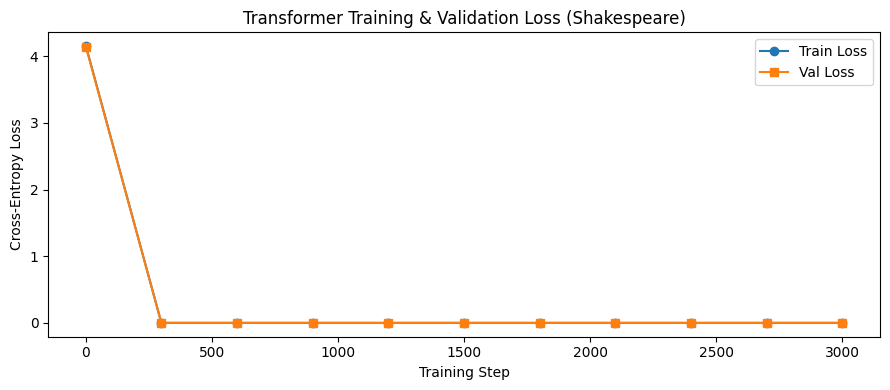

In [24]:
# Match exactly the steps where estimate_loss() is called in the training loop:
# step == 1, then every EVAL_INTERVAL up to MAX_ITERS  → 11 points total
eval_steps = [1] + list(range(EVAL_INTERVAL, MAX_ITERS + 1, EVAL_INTERVAL))

plt.figure(figsize=(9, 4))
plt.plot(eval_steps, train_losses, label='Train Loss', marker='o')
plt.plot(eval_steps, val_losses,   label='Val Loss',   marker='s')
plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Transformer Training & Validation Loss (Shakespeare)')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

## 9. Text Generation (Autoregressive Decoding)

In [25]:
@torch.no_grad()
def generate(model, prompt: str, max_new_tokens: int = 200, temperature: float = 1.0, top_k: int = 40):
    """Autoregressive generation with temperature scaling and top-k sampling.

    The encoder receives the full prompt; the decoder generates one token at a
    time, feeding its own outputs back as new decoder inputs.
    """
    model.eval()
    src = torch.tensor(encode(prompt), dtype=torch.long, device=DEVICE).unsqueeze(0)  # (1, T_src)
    memory = model.encoder(src)          # encode once  (1, T_src, D)

    # Decoder input starts with the prompt tokens
    dec_input = src.clone()              # (1, T)

    generated = list(encode(prompt))

    for _ in range(max_new_tokens):
        # Crop decoder context to BLOCK_SIZE
        dec_ctx = dec_input[:, -BLOCK_SIZE:]

        # Decoder forward
        dec_out = model.decoder(dec_ctx, memory)          # (1, T, D)
        logits  = model.output_proj(dec_out[:, -1, :])    # (1, V)  — last position

        # Temperature
        logits = logits / temperature

        # Top-k filtering
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        probs    = F.softmax(logits, dim=-1)
        next_tok = torch.multinomial(probs, num_samples=1)  # (1, 1)

        generated.append(next_tok.item())
        dec_input = torch.cat([dec_input, next_tok], dim=1)

    return decode(generated)


prompt_text = "ROMEO:"
output = generate(model, prompt_text, max_new_tokens=300, temperature=0.8, top_k=40)
print("=" * 60)
print(output)
print("=" * 60)

ROMEO:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH


## 10. Architecture Summary

| Component | Details |
|---|---|
| Token Embedding | `nn.Embedding(vocab_size, d_model)` — shared across enc/dec/output |
| Positional Encoding | Sinusoidal (fixed), added to scaled embeddings |
| **Encoder** | N × `EncoderLayer` → LayerNorm |
| Encoder Layer | Multi-Head Self-Attn → Add&Norm → FFN → Add&Norm |
| **Decoder** | N × `DecoderLayer` → LayerNorm |
| Decoder Layer | Masked Self-Attn → Add&Norm → Cross-Attn → Add&Norm → FFN → Add&Norm |
| Output Head | Linear projection → vocabulary logits |
| Attention | Scaled dot-product, optional causal mask for decoder |
| Optimizer | AdamW + Cosine LR schedule |
| Regularisation | Dropout on attention weights, FFN, embeddings; gradient clipping |

### Key Design Choices
- **Weight tying**: encoder embedding = decoder embedding = output projection weight matrix — reduces parameters and improves generalisation.
- **Causal masking** in decoder self-attention prevents the model from attending to future tokens during training.
- **Cross-attention** allows each decoder position to attend over the full encoder output (memory).
- **Temperature + Top-k sampling** at inference gives controllable diversity in generated text.